# Iris Classification: LDA vs PCA

This notebook compares two popular dimensionality reduction techniques:

- **Linear Discriminant Analysis (LDA)**
- **Principal Component Analysis (PCA)**

## Objective

Demonstrate how LDA and PCA affect classification performance on the Iris flower dataset.

## What we will do

1. Load the Iris dataset
2. Apply PCA to reduce dimensionality
3. Apply LDA to reduce dimensionality
4. Train a classifier on each transformed dataset
5. Compare the classification accuracy and performance

## Why this matters

- PCA is an unsupervised method that finds directions of maximal variance.
- LDA is a supervised method that finds directions that best separate the classes.

By comparing them, we can see how using label information in LDA may impact classification performance versus using PCA alone.

## 1. Load the Iris dataset

In [40]:
from sklearn.datasets import load_iris
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [41]:
# Load the iris dataset
iris = load_iris(return_X_y=True)
X, y = iris

In [42]:
# Read feature names and target names
# feature names
feature_names = [
    "sepal_length",
    "sepal_width",
    "petal_length",
    "petal_width"
]

# Create DataFrame
df = pd.DataFrame(X, columns=feature_names)

# Add target column
df["target"] = y

# Display first 5 rows
print(df.head())

   sepal_length  sepal_width  petal_length  petal_width  target
0           5.1          3.5           1.4          0.2       0
1           4.9          3.0           1.4          0.2       0
2           4.7          3.2           1.3          0.2       0
3           4.6          3.1           1.5          0.2       0
4           5.0          3.6           1.4          0.2       0


In [43]:
print("Missing values per column:")
print(df.isnull().sum())

print("\nTotal missing values:")
print(df.isnull().sum().sum())

Missing values per column:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
target          0
dtype: int64

Total missing values:
0


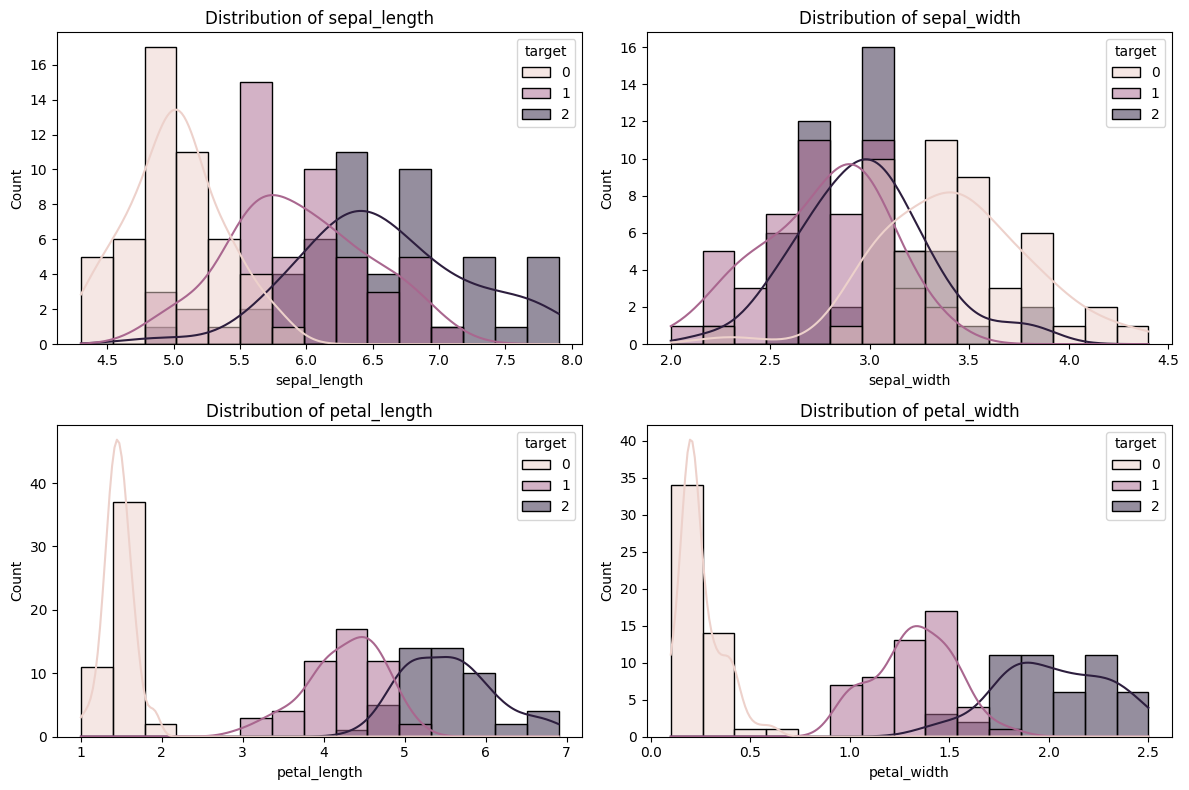

In [44]:
features = [col for col in df.columns if col != 'target']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, feature in enumerate(features):
    sns.histplot(
        data=df,
        x=feature,
        hue='target',
        bins=15,
        kde=True,
        ax=axes[i]
    )
    axes[i].set_title(f'Distribution of {feature}')

plt.tight_layout()
plt.show()

## 2. Apply PCA to reduce dimensionality

In [45]:
from sklearn.decomposition import PCA

In [46]:
pca = PCA(n_components=2)

In [47]:
X_pca = pca.fit_transform(X)

In [48]:
species_names = ['setosa', 'versicolor', 'virginica']

pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

pca_df["species"] = [species_names[i] for i in y]

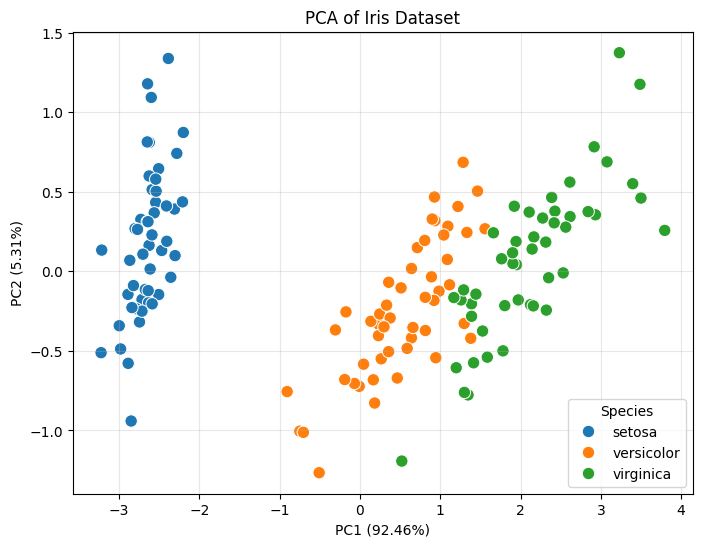

In [49]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="species",
    s=80
)

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)")
plt.title("PCA of Iris Dataset")
plt.legend(title="Species")
plt.grid(alpha=0.3)

plt.show()

In [50]:
print(pca.explained_variance_ratio_)
print("Total:", pca.explained_variance_ratio_.sum())

[0.92461872 0.05306648]
Total: 0.9776852063187963


## 3. Apply LDA to reduce dimensionality

In [51]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

In [53]:
# The number of dimensions will be one less than the number of classes.
lda = LinearDiscriminantAnalysis(n_components=2)

In [54]:
X_lda = lda.fit_transform(X, y)

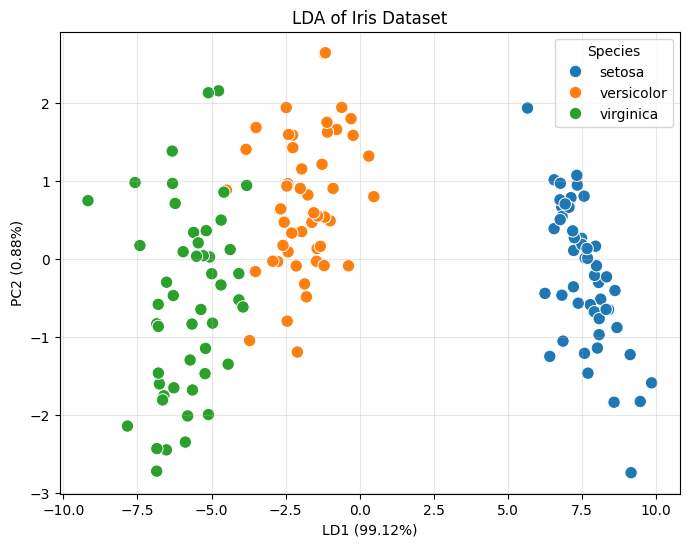

In [55]:
species_names = ['setosa', 'versicolor', 'virginica']

lda_df = pd.DataFrame(
    X_lda,
    columns=["LD1", "LD2"]
)

lda_df["species"] = [species_names[i] for i in y]

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=lda_df,
    x="LD1",
    y="LD2",
    hue="species",
    s=80
)

plt.xlabel(f"LD1 ({lda.explained_variance_ratio_[0]*100:.2f}%)")
plt.ylabel(f"PC2 ({lda.explained_variance_ratio_[1]*100:.2f}%)")
plt.title("LDA of Iris Dataset")
plt.legend(title="Species")
plt.grid(alpha=0.3)
plt.show()

## 4. Train a classifier on each transformed dataset

- A good choice for linear classification is Logistic Regression.

### PCA

In [75]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, f1_score

In [63]:
# Making a classifier for PCA
clf_pca = LogisticRegression(max_iter=1000)

In [64]:
# Data splitting that reduces dimensionality with PCA
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(
    X_pca,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

In [65]:
# Training on the PCA classifier model
clf_pca.fit(X_train_pca, y_train_pca)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [66]:
y_pred_pca = clf_pca.predict(X_test_pca)

In [67]:
print("PCA Results")
print("Accuracy:", accuracy_score(y_test_pca, y_pred_pca))
print(classification_report(y_test_pca, y_pred_pca))

PCA Results
Accuracy: 0.9111111111111111
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       0.82      0.93      0.88        15
           2       0.92      0.80      0.86        15

    accuracy                           0.91        45
   macro avg       0.92      0.91      0.91        45
weighted avg       0.92      0.91      0.91        45



### LDA

In [68]:
# Making a classifier for LDA
clf_lda = LogisticRegression(max_iter=1000)

In [69]:
# Data splitting that reduces dimensionality with LDA
X_train_lda, X_test_lda, y_train_lda, y_test_lda = train_test_split(
    X_lda, y, test_size=0.2, random_state=42, stratify=y
)

In [70]:
# Training on the LDA classifier model
clf_lda.fit(X_train_lda, y_train_lda)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [71]:
# Predicting with the LDA model
y_pred_lda = clf_lda.predict(X_test_lda)

In [72]:
# Showing results for LDA
print("LDA Results")
print("Accuracy:", accuracy_score(y_test_lda, y_pred_lda))
print(classification_report(y_test_lda, y_pred_lda))    


LDA Results
Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00        10
           2       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



## 5. Compare the classification accuracy and performance

In [77]:
results = {
    "PCA": {
        "Accuracy": accuracy_score(y_test_pca, y_pred_pca),
        "F1_macro": f1_score(y_test_pca, y_pred_pca, average="macro")
    },
    "LDA": {
        "Accuracy": accuracy_score(y_test_lda, y_pred_lda),
        "F1_macro": f1_score(y_test_lda, y_pred_lda, average="macro")
    }
}


In [78]:
results_df = pd.DataFrame(results).T

results_df["Accuracy (%)"] = results_df["Accuracy"] * 100
results_df["F1_macro (%)"] = results_df["F1_macro"] * 100

results_df = results_df[["Accuracy (%)", "F1_macro (%)"]]

print(results_df.round(2))

     Accuracy (%)  F1_macro (%)
PCA         91.11         91.07
LDA        100.00        100.00


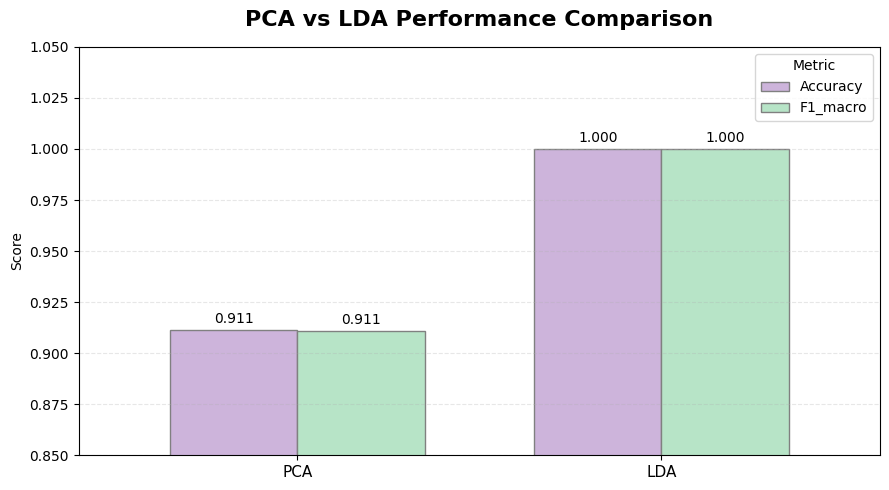

In [86]:
results_df = pd.DataFrame(results).T

pastel_colors = ["#CDB4DB", "#B7E4C7"]

fig, ax = plt.subplots(figsize=(9, 5))

results_df.plot(
    kind="bar",
    ax=ax,
    color=pastel_colors,
    width=0.7,
    edgecolor="gray"
)

ax.set_title(
    "PCA vs LDA Performance Comparison",
    fontsize=16,
    fontweight="bold",
    pad=15
)

ax.set_ylabel("Score")
ax.set_xlabel("")
ax.set_ylim(0.85, 1.05)

ax.grid(axis="y", linestyle="--", alpha=0.3)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.3f",
        padding=3,
        fontsize=10
    )

ax.legend(
    title="Metric",
    frameon=True,
    fancybox=True
)

plt.xticks(rotation=0, fontsize=11)
plt.tight_layout()
plt.show()